<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Creating-the-Gene-Table" data-toc-modified-id="Creating-the-Gene-Table-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Creating the Gene Table</a></span><ul class="toc-item"><li><span><a href="#Get-information-from-GFF-files" data-toc-modified-id="Get-information-from-GFF-files-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Get information from GFF files</a></span></li><li><span><a href="#(Optional)-KEGG-and-COGs" data-toc-modified-id="(Optional)-KEGG-and-COGs-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>(Optional) KEGG and COGs</a></span><ul class="toc-item"><li><span><a href="#Generate-nucleotide-fasta-files-for-CDS" data-toc-modified-id="Generate-nucleotide-fasta-files-for-CDS-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Generate nucleotide fasta files for CDS</a></span></li><li><span><a href="#Run-EggNOG-Mapper" data-toc-modified-id="Run-EggNOG-Mapper-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Run EggNOG Mapper</a></span></li><li><span><a href="#Get-KEGG-IDs" data-toc-modified-id="Get-KEGG-IDs-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Get KEGG IDs</a></span></li><li><span><a href="#Save-KEGG-information" data-toc-modified-id="Save-KEGG-information-1.2.4"><span class="toc-item-num">1.2.4&nbsp;&nbsp;</span>Save KEGG information</a></span></li><li><span><a href="#Save-COGs-to-annotation-dataframe" data-toc-modified-id="Save-COGs-to-annotation-dataframe-1.2.5"><span class="toc-item-num">1.2.5&nbsp;&nbsp;</span>Save COGs to annotation dataframe</a></span></li></ul></li><li><span><a href="#Uniprot-ID-mapping" data-toc-modified-id="Uniprot-ID-mapping-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Uniprot ID mapping</a></span></li><li><span><a href="#Add-Biocyc-Operon-information" data-toc-modified-id="Add-Biocyc-Operon-information-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Add Biocyc Operon information</a></span><ul class="toc-item"><li><span><a href="#Assign-unique-IDs-to-operons" data-toc-modified-id="Assign-unique-IDs-to-operons-1.4.1"><span class="toc-item-num">1.4.1&nbsp;&nbsp;</span>Assign unique IDs to operons</a></span></li></ul></li><li><span><a href="#Clean-up-and-save-annotation" data-toc-modified-id="Clean-up-and-save-annotation-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Clean up and save annotation</a></span></li><li><span><a href="#Final-statistics" data-toc-modified-id="Final-statistics-1.6"><span class="toc-item-num">1.6&nbsp;&nbsp;</span>Final statistics</a></span></li><li><span><a href="#Fill-missing-values" data-toc-modified-id="Fill-missing-values-1.7"><span class="toc-item-num">1.7&nbsp;&nbsp;</span>Fill missing values</a></span></li><li><span><a href="#GO-Annotations" data-toc-modified-id="GO-Annotations-1.8"><span class="toc-item-num">1.8&nbsp;&nbsp;</span>GO Annotations</a></span></li></ul></li></ul></div>


#### NOTE: This is for C. thermocellum

# Creating the Gene Table
This notebook is copied from the [Pymodulon GitHub repository](https://github.com/SBRG/pymodulon/blob/master/docs/tutorials/creating_the_gene_table.ipynb)

In [1]:
from pymodulon.gene_util import *
import os

## Get information from GFF files

First, download the FASTA and GFF files for your organism and its plasmids from NCBI.

Enter the location of all your GFF files here:

In [2]:
gff_files = [os.path.join('..','ctherm_nf','sequence_files','genome.gff3')]

The following cell will convert all the GFF files into a single Pandas DataFrame for easy manipulation. Pseudogenes have multiple rows in a GFF file (one for each fragment), but only the first fragment will be kept.

In [3]:
keep_cols = ['accession','start','end','strand','gene_name','old_locus_tag','gene_product','ncbi_protein']

DF_annot = gff2pandas(gff_files,index='locus_tag')
DF_annot = DF_annot[keep_cols]

DF_annot.head()

,accession,start,end,strand,gene_name,old_locus_tag,gene_product,ncbi_protein
locus_tag,,,,,,,,
Clo1313_0001,CP002416.1,212,1543,+,None,None,chromosomal replication initiator protein DnaA,ADU73101.1
Clo1313_0002,CP002416.1,1793,2893,+,None,None,DNA polymerase III%2C beta subunit,ADU73102.1
Clo1313_0003,CP002416.1,2909,3115,+,None,None,S4 domain protein YaaA,ADU73103.1
Clo1313_0004,CP002416.1,3133,4242,+,None,None,DNA replication and repair protein RecF,ADU73104.1
Clo1313_0005,CP002416.1,4410,4724,+,None,None,hypothetical protein,ADU73105.1


To ensure that the gene index used is identical to the expression matrix, load in your data.

In [4]:
log_tpm_file = os.path.join('..', 'ctherm_nf', 'processed_data','log_tpm.csv')
DF_log_tpm = pd.read_csv(log_tpm_file,index_col=0)
DF_log_tpm.head()

,SRX1014220,SRX1014221,SRX1014225,SRX1014226,SRX1014227,SRX1014228,SRX1014230,SRX1014231,SRX1014232,SRX1014233,...,SRX7195451,SRX7195452,SRX7195453,SRX7195454,SRX7195455,SRX7195456,SRX7195457,SRX7195458,SRX7195460,SRX7195461
Geneid,,,,,,,,,,,,,,,,,,,,,
Clo1313_0001,7.551777,7.731136,6.375955,6.322270,6.423123,7.645399,7.527894,8.227711,7.499026,7.990460,...,8.661411,8.472448,8.591866,8.263745,8.270868,8.044656,8.326490,8.740112,8.263641,7.529287
Clo1313_0002,7.752602,8.004967,5.543052,5.438840,5.654808,7.980810,7.782816,8.124167,7.780386,8.047120,...,8.443217,8.080222,8.307475,7.997551,8.130777,7.552272,8.061540,8.474935,7.917540,7.321251
Clo1313_0003,8.887143,9.171801,6.211352,6.098789,6.254218,9.203208,8.993602,9.383468,8.842177,9.288886,...,7.843315,7.546721,7.800770,7.385063,7.535819,6.724409,7.487562,7.825918,7.399767,6.911327
Clo1313_0004,7.043892,7.110695,4.387811,4.406844,4.493506,7.074095,6.846041,7.339102,7.101972,7.241472,...,7.066704,6.792801,6.996588,6.473204,6.670690,6.217058,6.608325,6.879623,6.553680,5.919809
Clo1313_0005,7.979446,8.252763,7.266938,7.243592,7.191651,8.453759,8.452603,8.736243,8.297923,8.823000,...,7.621218,8.427785,7.601650,7.705822,7.770806,8.178356,7.752933,7.833385,7.828161,7.648701


Check that the genes are the same in the expression dataset as in the annotation dataframe. Mismatched genes are listed below.

In [5]:
test = DF_annot.sort_index().index == DF_log_tpm.sort_index().index
DF_annot[~test]

,accession,start,end,strand,gene_name,old_locus_tag,gene_product,ncbi_protein
locus_tag,,,,,,,,


## (Optional) KEGG and COGs

### Generate nucleotide fasta files for CDS

Enter the location of all your fasta files here:

In [ ]:
fasta_files = [os.path.join('..','ctherm_nf','sequence_files','genome.fasta')]

The following code generates CDS files using your FASTA and GFF3 files

In [ ]:
from Bio import SeqIO

cds_list = []
for fasta in fasta_files:
    seq = SeqIO.read(fasta,'fasta')

    # Get gene information for genes in this fasta file
    df_genes = DF_annot[DF_annot.accession == seq.id]
    
    for i,row in df_genes.iterrows():
        cds = seq[row.start-1:row.end]
        if row.strand == '-':
            cds = seq[row.start-1:row.end].reverse_complement()
        cds.id = row.name
        cds.description = row.gene_name if pd.notnull(row.gene_name) else row.name
        cds_list.append(cds)

Save the CDS file

In [ ]:
cds_file = os.path.join('..', 'ctherm_nf', 'sequence_files', 'CDS.fna')
SeqIO.write(cds_list, cds_file, 'fasta')

### Run EggNOG Mapper

NOTE: I am using Galaxy: [usegalaxy.eu](https://usegalaxy.eu/root?tool_id=eggnog_mapper). Here is the syntax:

`emapper.py  --data_dir '/data/db/data_managers/eggnog_data/5.0.2'   -m 'diamond' -i '/data/dnb12/galaxy_db/files/3/1/2/dataset_31211297-4911-4c8d-9a00-55a2be531c2d.dat' --itype 'CDS' --translate   --matrix 'BLOSUM62' --gapopen 11 --gapextend 1 --sensmode sensitive --dmnd_iterate no   --score 0.001   --seed_ortholog_evalue 0.001 --target_orthologs=all --go_evidence=non-electronic \$EGGNOG_DBMEM  --no_file_comments   --output='results' --cpu "\${GALAXY_SLOTS:-4}" --scratch_dir \${TEMP:-\$_GALAXY_JOB_TMP_DIR} --temp_dir \${TEMP:-\$_GALAXY_JOB_TMP_DIR}`

### Get KEGG IDs
- Once you have the EggNOG annotations, load the annotation file

In [8]:
eggnog_file = os.path.join('..', 'ctherm_nf','external','eggnog_annotations_galaxy.tab')

In [ ]:
DF_eggnog = pd.read_csv(eggnog_file,sep='\t',skiprows=5,header=None)
eggnog_cols = ['query_name','seed eggNOG ortholog','seed ortholog evalue','seed ortholog score',
               'eggNOG OGs','max_annot_lvl','COG','Description','Preferred_name','GOs',
               'EC number','KEGG_ko','KEGG_pathway','KEGG_module','KEGG_reaction','KEGG_rclass',
               'BRITE','KEGG_TC','CAZy','BiGG Reaction','PFAMs']

DF_eggnog.columns = eggnog_cols

# Strip last three rows as they are comments
DF_eggnog = DF_eggnog.iloc[:-3]

# Set locus tag as index
DF_eggnog = DF_eggnog.set_index('query_name')
DF_eggnog.index.name = 'locus_tag'

DF_eggnog.head(5)

,seed eggNOG ortholog,seed ortholog evalue,seed ortholog score,eggNOG OGs,max_annot_lvl,COG,Description,Preferred_name,GOs,EC number,KEGG_ko,KEGG_pathway,KEGG_module,KEGG_reaction,KEGG_rclass,BRITE,KEGG_TC,CAZy,BiGG Reaction,PFAMs
locus_tag,,,,,,,,,,,,,,,,,,,,
Clo1313_0005,203119.Cthe_2375,3.630000e-57,178.0,"2E36Q@1|root,32Y6E@2|Bacteria,1VEZV@1239|Firmi...",186801|Clostridia,S,Domain of unknown function (DUF370),-,-,-,-,-,-,-,-,-,-,-,-,DUF370
Clo1313_0006,203119.Cthe_2376,0.000000e+00,1277.0,"COG0187@1|root,COG0187@2|Bacteria,1TQ0R@1239|F...",186801|Clostridia,L,A type II topoisomerase that negatively superc...,gyrB,-,5.99.1.3,ko:K02470,-,-,-,-,"ko00000,ko01000,ko03032,ko03400",-,-,-,"DNA_gyraseB,DNA_gyraseB_C,HATPase_c,Toprim"
Clo1313_0007,203119.Cthe_2377,2.790000e-179,499.0,"COG1192@1|root,COG1192@2|Bacteria,1TP8S@1239|F...",186801|Clostridia,D,CobQ CobB MinD ParA nucleotide binding domain,soj,-,-,ko:K03496,-,-,-,-,"ko00000,ko03036,ko04812",-,-,-,AAA_31
Clo1313_0008,203119.Cthe_2378,8.630000e-194,539.0,"COG1475@1|root,COG1475@2|Bacteria,1TQ2B@1239|F...",186801|Clostridia,K,Belongs to the ParB family,spo0J,-,-,ko:K03497,-,-,-,-,"ko00000,ko03000,ko03036,ko04812",-,-,-,ParBc
Clo1313_0009,203119.Cthe_2379,1.060000e-105,306.0,"COG1196@1|root,COG1196@2|Bacteria,1VAV4@1239|F...",186801|Clostridia,D,Protein of unknown function (DUF4446),-,-,-,-,-,-,-,-,-,-,-,-,DUF4446
Clo1313_0010,203119.Cthe_2380,4.110000e-127,367.0,"2DZFJ@1|root,32V9E@2|Bacteria,1VA2I@1239|Firmi...",186801|Clostridia,-,-,-,-,-,-,-,-,-,-,-,-,-,-,TPR_6
Clo1313_0011,203119.Cthe_2381,6.300000e-291,796.0,"COG0172@1|root,COG0172@2|Bacteria,1TP4W@1239|F...",186801|Clostridia,J,Catalyzes the attachment of serine to tRNA(Ser...,serS,-,6.1.1.11,ko:K01875,"ko00970,map00970","M00359,M00360","R03662,R08218","RC00055,RC00523","ko00000,ko00001,ko00002,ko01000,ko01007,ko03016",-,-,-,"Seryl_tRNA_N,tRNA-synt_2b"
Clo1313_0012,203119.Cthe_2382,0.000000e+00,890.0,"COG0477@1|root,COG2814@2|Bacteria,1UZSN@1239|F...",186801|Clostridia,EGP,PFAM Major Facilitator Superfamily,-,-,-,-,-,-,-,-,-,-,-,-,MFS_1
Clo1313_0013,203119.Cthe_2383,4.920000e-212,586.0,"COG2340@1|root,COG2340@2|Bacteria,1VEP7@1239|F...",186801|Clostridia,S,Copper amine oxidase N-terminal domain,-,-,-,-,-,-,-,-,-,-,-,-,Cu_amine_oxidN1


Now we will pull the KEGG information from the eggNOG file, including orthology, pathway, module, and reactions for each gene.

In [10]:
DF_kegg = DF_eggnog[['KEGG_pathway','KEGG_module','KEGG_reaction']]

# Melt dataframe
DF_kegg = DF_kegg.reset_index().melt(id_vars='locus_tag') 

# Remove null values
DF_kegg = DF_kegg[DF_kegg.value.notnull()]

# Split comma-separated values into their own rows
list2struct = []
for name,row in DF_kegg.iterrows():
    for val in row.value.split(','):
        list2struct.append([row.locus_tag,row.variable,val])

DF_kegg = pd.DataFrame(list2struct,columns=['gene_id','database','kegg_id'])

# Remove ko entries, as only map entries are searchable in KEGG pathway
DF_kegg = DF_kegg[~DF_kegg.kegg_id.str.startswith('ko')]

DF_kegg.head()

,gene_id,database,kegg_id
0,Clo1313_0005,KEGG_pathway,-
1,Clo1313_0006,KEGG_pathway,-
2,Clo1313_0007,KEGG_pathway,-
3,Clo1313_0008,KEGG_pathway,-
4,Clo1313_0009,KEGG_pathway,-


### Save KEGG information

In [11]:
DF_kegg.to_csv(os.path.join('..', 'ctherm_nf','external','kegg_mapping.csv'))

### Save COGs to annotation dataframe

In [12]:
DF_annot['COG'] = DF_eggnog.COG

# Make sure COG only has one entry per gene
DF_annot['COG'] = [item[0] if isinstance(item,str) else item for item in DF_annot['COG']]

## Uniprot ID mapping
Save the NCBI protein ID to a file for uniprot mapping

In [ ]:
with open(os.path.join('..', 'ctherm_nf', 'external','ncbi_protein.txt'), "w") as file:
    for item in DF_annot.ncbi_protein.fillna('').values:
        file.write(str(item)+"\n")
    file.close()

Map the NCBI protein IDs to Uniprot IDs
1. Go to https://www.uniprot.org/id-mapping/.
1. ~~Upload the `uniprot_mapping.txt` file from the `external` folder~~
1. Upload the `ncbi_protein.txt` file from the `external` folder.
1. For **"From database"**, choose **Sequence database --> EMBL-GenBank-DDBJ_CDS** if the FASTA/GFF files are from Genbank, choose **Sequence database --> RefSeq Nucleotide** if the files are from RefSeq. If hits are low, feel free to try out other databases 
1. Once the mapping completes, download the annotations file by clicking Download on the results page. Choose **"Download all"**, **"Format TSV"** 
1. Save the annotation file to the `external` folder, rename to `uniprot_mapping.tsv`

In [13]:
mapping_uniprot = pd.read_csv(os.path.join('..', 'ctherm_nf', 'external','uniprot_mapping.tsv'),sep = '\t')
mapping_uniprot = mapping_uniprot.rename(columns = {'from':'ncbi_protein','to':'uniprot'})[['ncbi_protein','uniprot']]
mapping_uniprot = mapping_uniprot.drop_duplicates('ncbi_protein')
mapping_uniprot.head()

,ncbi_protein,uniprot
0,ADU73101.1,UPI0001B1F046
1,ADU73102.1,UPI00017E1F7F
2,ADU73103.1,UPI000038F4E6
3,ADU73104.1,UPI00003C8C54
4,ADU73105.1,UPI000038F4E8


In [14]:
# Merge with current annotation
DF_annot = pd.merge(DF_annot.reset_index(),mapping_uniprot,how='left',on='ncbi_protein')
DF_annot.set_index('locus_tag',inplace=True)
DF_annot.head()

,accession,start,end,strand,gene_name,old_locus_tag,gene_product,ncbi_protein,COG,uniprot
locus_tag,,,,,,,,,,
Clo1313_0001,CP002416.1,212,1543,+,None,None,chromosomal replication initiator protein DnaA,ADU73101.1,NaN,UPI0001B1F046
Clo1313_0002,CP002416.1,1793,2893,+,None,None,DNA polymerase III%2C beta subunit,ADU73102.1,NaN,UPI00017E1F7F
Clo1313_0003,CP002416.1,2909,3115,+,None,None,S4 domain protein YaaA,ADU73103.1,NaN,UPI000038F4E6
Clo1313_0004,CP002416.1,3133,4242,+,None,None,DNA replication and repair protein RecF,ADU73104.1,NaN,UPI00003C8C54
Clo1313_0005,CP002416.1,4410,4724,+,None,None,hypothetical protein,ADU73105.1,S,UPI000038F4E8


## Add Biocyc Operon information

To obtain operon information from Biocyc, follow the steps below

1. Go to [Biocyc.org](https://biocyc.org/) (you may need to create an account and/or login)
2. Change the organism database to your organism/strain
3. Select **SmartTables** -> **Special SmartTables**
4. Select **"All genes of \<organism\>"**
5. Select the **"Gene Name"** column
6. Under **"ADD TRANSFORM COLUMN"** select **"Genes in same transcription unit"**
7. Select the **"Genes in same transcription unit"** column
8. Under **"ADD PROPERTY COLUMN"** select **"Accession-1"**
9. Under **OPERATIONS**, select **"Export"** -> **"to Spreadsheet File..."**
10. Select **"common names"** and click **"Export smarttable"**
11. Add file location below and run the code cell

### Exclusive to C. thermocellum:
1. Ensure that Accession-2 is chosen because the locus tags have changed. Accession-1 are new ones. I need old ones.

In [15]:
biocyc_file = os.path.join('..', 'ctherm_nf','external', 'biocyc_annotations.txt')

DF_biocyc = pd.read_csv(biocyc_file,sep='\t')

DF_biocyc.head()

,Gene Name,Accession-1,Left-End-Position,Right-End-Position,Product,Genes in same transcription unit,Accession-2,Accession-1.1,Accession-2.1
0,RS04120,CLO1313_RS04120,925215,925673,MarR family transcriptional regulator,RS04125 // RS04120,Clo1313_0802,RS04125 // RS04120,Clo1313_0803 // Clo1313_0802
1,RS08325,CLO1313_RS08325,1925487,1926263,hypothetical protein,RS15620 // RS08325,Clo1313_1649,RS15620 // RS08325,Clo1313_1650 // Clo1313_1649
2,RS15215,CLO1313_RS15215,3507716,3508414,response regulator transcription factor,RS15215,Clo1313_2994,CLO1313_RS15215,Clo1313_2994
3,RS04355,CLO1313_RS04355,976309,976641,hypothetical protein,RS04355,Clo1313_0848,CLO1313_RS04355,Clo1313_0848
4,RS11765,CLO1313_RS11765,2726957,2727349,hypothetical protein,RS11765,Clo1313_2317,CLO1313_RS11765,Clo1313_2317


In [ ]:
#For C. thermocellum, Use Accession-2

# Remove genes with no accession
DF_biocyc = DF_biocyc[DF_biocyc['Accession-2'].notnull()] 

# Set the accession (i.e. locus tag) as index
DF_biocyc = DF_biocyc.set_index('Accession-2').sort_values('Left-End-Position') #

# Only keep genes in the final annotation file
DF_biocyc = DF_biocyc.reindex(DF_annot.index)

# Reformat transcription units
DF_biocyc['operon_list'] = DF_biocyc['Accession-2.1'].apply(reformat_biocyc_tu)

# Fill None with locus tags
DF_biocyc['operon_list'].fillna(DF_biocyc.index.to_series(), inplace=True)

DF_biocyc.head()

/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/860084861.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DF_biocyc['operon_list'].fillna(DF_biocyc.index.to_series(), inplace=True)


,Gene Name,Accession-1,Left-End-Position,Right-End-Position,Product,Genes in same transcription unit,Accession-1.1,Accession-2.1,operon_list
locus_tag,,,,,,,,,
Clo1313_0001,dnaA,CLO1313_RS00010,212.0,1543.0,chromosomal replication initiator protein DnaA,dnaA,CLO1313_RS00010,Clo1313_0001,Clo1313_0001
Clo1313_0002,RS00015,CLO1313_RS00015,1793.0,2893.0,DNA polymerase III subunit beta,recF // yaaA // RS00015,recF // yaaA // RS00015,Clo1313_0004 // Clo1313_0003 // Clo1313_0002,Clo1313_0002;Clo1313_0003;Clo1313_0004
Clo1313_0003,yaaA,CLO1313_RS00020,2909.0,3115.0,S4 domain-containing protein YaaA,recF // yaaA // RS00015,recF // yaaA // RS00015,Clo1313_0004 // Clo1313_0003 // Clo1313_0002,Clo1313_0002;Clo1313_0003;Clo1313_0004
Clo1313_0004,recF,CLO1313_RS00025,3133.0,4242.0,DNA replication/repair protein RecF,recF // yaaA // RS00015,recF // yaaA // RS00015,Clo1313_0004 // Clo1313_0003 // Clo1313_0002,Clo1313_0002;Clo1313_0003;Clo1313_0004
Clo1313_0005,RS00030,CLO1313_RS00030,4410.0,4724.0,DUF370 domain-containing protein,RS00030,CLO1313_RS00030,Clo1313_0005,Clo1313_0005


### Assign unique IDs to operons
- The following code assigns unique names to each operon

In [17]:
# Get all operons
operons = DF_biocyc['operon_list'].unique()

# Map each operon to a unique string
operon_dict = {operon: "Op"+str(i) for i, operon in enumerate(operons)}

# Add names to dataframe
DF_biocyc['operon'] = [operon_dict[op] for op in DF_biocyc["operon_list"]]

DF_biocyc.head()

,Gene Name,Accession-1,Left-End-Position,Right-End-Position,Product,Genes in same transcription unit,Accession-1.1,Accession-2.1,operon_list,operon
locus_tag,,,,,,,,,,
Clo1313_0001,dnaA,CLO1313_RS00010,212.0,1543.0,chromosomal replication initiator protein DnaA,dnaA,CLO1313_RS00010,Clo1313_0001,Clo1313_0001,Op0
Clo1313_0002,RS00015,CLO1313_RS00015,1793.0,2893.0,DNA polymerase III subunit beta,recF // yaaA // RS00015,recF // yaaA // RS00015,Clo1313_0004 // Clo1313_0003 // Clo1313_0002,Clo1313_0002;Clo1313_0003;Clo1313_0004,Op1
Clo1313_0003,yaaA,CLO1313_RS00020,2909.0,3115.0,S4 domain-containing protein YaaA,recF // yaaA // RS00015,recF // yaaA // RS00015,Clo1313_0004 // Clo1313_0003 // Clo1313_0002,Clo1313_0002;Clo1313_0003;Clo1313_0004,Op1
Clo1313_0004,recF,CLO1313_RS00025,3133.0,4242.0,DNA replication/repair protein RecF,recF // yaaA // RS00015,recF // yaaA // RS00015,Clo1313_0004 // Clo1313_0003 // Clo1313_0002,Clo1313_0002;Clo1313_0003;Clo1313_0004,Op1
Clo1313_0005,RS00030,CLO1313_RS00030,4410.0,4724.0,DUF370 domain-containing protein,RS00030,CLO1313_RS00030,Clo1313_0005,Clo1313_0005,Op2


#### create annotation from Biocyc for C. thermocellum

In [18]:
df_biocyc_pathways = pd.read_csv(os.path.join('..', 'ctherm_nf','external', 'biocyc_pathways.txt'), sep='\t')

df_biocyc_pathways = df_biocyc_pathways[['Pathways', 'Accession-2']]

df_biocyc_pathways['Accession-2'].fillna('', inplace=True)

df_biocyc_pathways_v1 = pd.DataFrame(df_biocyc_pathways['Accession-2'].str.split(' // ').tolist(), index=df_biocyc_pathways['Pathways']).stack()

# # reset index and rename columns
df_biocyc_pathways_v1 = df_biocyc_pathways_v1.reset_index(['Pathways', 0])

df_biocyc_pathways_v1 = df_biocyc_pathways_v1[[0, 'Pathways']]

df_biocyc_pathways_v1.columns = ['gene_id','biocyc_pathways']

df_biocyc_pathways_v1.to_csv(os.path.join('..', 'ctherm_nf', 'external', 'biocyc_pathways_curated.csv'))


/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/1109466662.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_biocyc_pathways['Accession-2'].fillna('', inplace=True)


### For C. therm, gene name needs to added from biocyc directly
- Finally, merge the Biocyc information with the main annotation DataFrame

In [19]:
DF_annot.head()

,accession,start,end,strand,gene_name,old_locus_tag,gene_product,ncbi_protein,COG,uniprot
locus_tag,,,,,,,,,,
Clo1313_0001,CP002416.1,212,1543,+,None,None,chromosomal replication initiator protein DnaA,ADU73101.1,NaN,UPI0001B1F046
Clo1313_0002,CP002416.1,1793,2893,+,None,None,DNA polymerase III%2C beta subunit,ADU73102.1,NaN,UPI00017E1F7F
Clo1313_0003,CP002416.1,2909,3115,+,None,None,S4 domain protein YaaA,ADU73103.1,NaN,UPI000038F4E6
Clo1313_0004,CP002416.1,3133,4242,+,None,None,DNA replication and repair protein RecF,ADU73104.1,NaN,UPI00003C8C54
Clo1313_0005,CP002416.1,4410,4724,+,None,None,hypothetical protein,ADU73105.1,S,UPI000038F4E8


In [20]:
DF_annot['operon'] = DF_biocyc['operon']

# this is specific to C. thermocellum
for x in DF_annot.index.to_list():
    DF_annot.loc[x, 'gene_name'] = DF_biocyc.loc[x, 'Gene Name']
# this is specific to C. thermocellum

## Clean up and save annotation

First, we will re-order the annotation columns

In [ ]:
if 'old_locus_tag' in DF_annot.columns:
    order = ['gene_name','accession','old_locus_tag','start','end','strand','gene_product','COG','uniprot','operon']
else:
    order = ['gene_name','accession','start','end','strand','gene_product','COG','uniprot','operon']
    
DF_annot = DF_annot[order]

## Final statistics

The following graphs show how much information is available for the organism.

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')

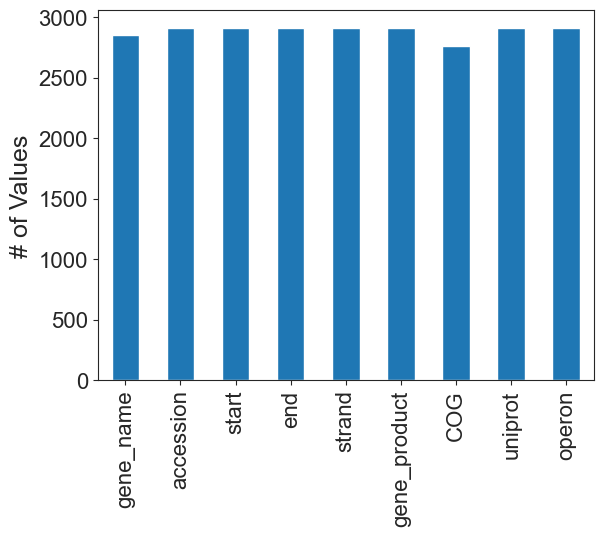

In [25]:
fig,ax = plt.subplots()
DF_annot.drop(['old_locus_tag'], axis=1).count().plot(kind='bar',ax=ax)
ax.set_ylabel('# of Values',fontsize=18)
ax.tick_params(labelsize=16)

## Fill missing values

Some organisms are missing gene names, so these will be filled with locus tag gene names.

In [26]:
# Fill in missing gene names with locus tag names
DF_annot['tmp_name'] = DF_annot.copy().index.tolist()
DF_annot.gene_name.fillna(DF_annot.tmp_name,inplace=True)
DF_annot.drop('tmp_name',axis=1,inplace=True)

/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/2238960056.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DF_annot.gene_name.fillna(DF_annot.tmp_name,inplace=True)


 COG letters will also be converted to the full name.

/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/2811350855.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DF_annot['COG'].fillna('X',inplace=True)


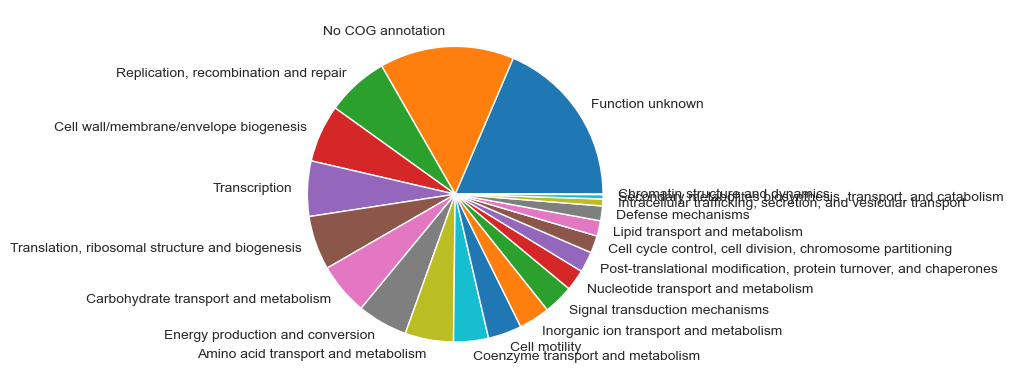

In [27]:
# Fill missing COGs with X
DF_annot['COG'].fillna('X',inplace=True)
DF_annot['COG'] = DF_annot['COG'].str.replace('-', 'X')

# Change single letter COG annotation to full description
DF_annot['COG'] = DF_annot.COG.apply(cog2str)

counts = DF_annot.COG.value_counts()
plt.pie(counts.values,labels=counts.index);


# save
plt.savefig('../ctherm_nf/external/all_cog_annotations_ctherm.png', dpi=300, transparent=True)

## GO Annotations

### For C. thermocellum, organism Acetivibrio thermocellus was chosen. This does not work. Only a few genes.
- Using Uniprot GO annotations directly

In [148]:
mapping_uniprot_detailed = pd.read_csv(os.path.join('..', 'ctherm_nf', 'external','uniprot_mapping_detailed.tsv'),sep = '\t')
mapping_uniprot_detailed['Gene Names'] = mapping_uniprot_detailed['Gene Names'].str.split(' ')

mapping_uniprot_detailed['gene_name'] = ''

# gene names
for x in mapping_uniprot_detailed.index.to_list():
    if isinstance(mapping_uniprot_detailed.loc[x, 'Gene Names'], float):
        mapping_uniprot_detailed.loc[x, 'gene_name'] = ''
    elif isinstance(mapping_uniprot_detailed.loc[x, 'Gene Names'], list):
        mapping_uniprot_detailed.loc[x, 'gene_name'] = mapping_uniprot_detailed.loc[x, 'Gene Names'][0]
    else:
        mapping_uniprot_detailed.loc[x, 'gene_name'] = mapping_uniprot_detailed.loc[x, 'Gene Names']


# Gene Ontology (GO)
mapping_uniprot_detailed['GO_names_bp'] = mapping_uniprot_detailed['Gene Ontology (biological process)'].str.replace(r' \[GO:\d+\]', '', regex=True).fillna(mapping_uniprot_detailed['Gene Ontology (biological process)'])
mapping_uniprot_detailed['GO_names_mf'] = mapping_uniprot_detailed['Gene Ontology (molecular function)'].str.replace(r' \[GO:\d+\]', '', regex=True).fillna(mapping_uniprot_detailed['Gene Ontology (molecular function)'])

########## MOLECULAR FUNCTION ##########
DF_GO_mf = mapping_uniprot_detailed[['gene_name', 'GO_names_mf']]
DF_GO_mf.columns = ['gene_name','gene_ontology']
DF_GO_mf.drop_duplicates(keep='first', inplace=True)

DF_GO_mf['gene_ontology'].fillna('', inplace=True)
DF_GO_mf = pd.DataFrame(DF_GO_mf['gene_ontology'].str.split(';').tolist(), index=DF_GO_mf['gene_name']).stack()

DF_GO_mf = DF_GO_mf.reset_index(['gene_name', 0])
DF_GO_mf.columns = ['gene_name','gene_ontology']


# Convert the gene names to gene locus tags, and drop gene names that cannot be converted
name2num = {v:k for k,v in DF_annot.gene_name.to_dict().items()}
DF_GO_mf['gene_id'] = [name2num[x] if x in name2num.keys() else None for x in DF_GO_mf.gene_name]

print(DF_GO_mf.head(2))

# Now we remove null entries
DF_GO_mf = DF_GO_mf[DF_GO_mf.gene_id.notnull()]

# save
DF_GO_mf[['gene_id','gene_name','gene_ontology']].to_csv(os.path.join('..', 'ctherm_nf', 'external','GO_annotations_MF_curated.csv'))


########## BIOLOGICAL PROCESS ##########
DF_GO_bp = mapping_uniprot_detailed[['gene_name', 'GO_names_bp']]
DF_GO_bp.columns = ['gene_name','gene_ontology']
DF_GO_bp.drop_duplicates(keep='first', inplace=True)

DF_GO_bp['gene_ontology'].fillna('', inplace=True)
DF_GO_bp = pd.DataFrame(DF_GO_bp['gene_ontology'].str.split(';').tolist(), index=DF_GO_bp['gene_name']).stack()

DF_GO_bp = DF_GO_bp.reset_index(['gene_name', 0])
DF_GO_bp.columns = ['gene_name','gene_ontology']


# Convert the gene names to gene locus tags, and drop gene names that cannot be converted
name2num = {v:k for k,v in DF_annot.gene_name.to_dict().items()}
DF_GO_bp['gene_id'] = [name2num[x] if x in name2num.keys() else None for x in DF_GO_bp.gene_name]

print(DF_GO_bp.head(2))

# Now we remove null entries
DF_GO_bp = DF_GO_bp[DF_GO_bp.gene_id.notnull()]

# save
DF_GO_bp[['gene_id','gene_name','gene_ontology']].to_csv(os.path.join('..', 'ctherm_nf', 'external','GO_annotations_BP_curated.csv'))

  gene_name                    gene_ontology       gene_id
0      dnaA                      ATP binding  Clo1313_0001
1      dnaA   DNA replication origin binding  Clo1313_0001
  gene_name                   gene_ontology       gene_id
0      dnaA      DNA replication initiation  Clo1313_0001
1      dnaA   regulation of DNA replication  Clo1313_0001


/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/606053519.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_GO_mf.drop_duplicates(keep='first', inplace=True)
/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/606053519.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DF_GO_mf['gene_ontology'].fillna('', i

### Interpro -- retreived from the file uniprot_mapping_detailed.tsv

In [149]:
mapping_uniprot_detailed = pd.read_csv(os.path.join('..', 'ctherm_nf', 'external','uniprot_mapping_detailed.tsv'),sep = '\t', index_col=0)

# create interpro data
DF_interpro = pd.DataFrame(mapping_uniprot_detailed['InterPro'])
DF_interpro.reset_index(inplace=True)
DF_interpro.drop_duplicates(subset=['From'], keep='first', inplace=True)

# add locus tag
for idx in DF_annot.index.to_list():
    uniprot = DF_annot.loc[idx, 'uniprot']
    DF_interpro.loc[DF_interpro['From']==uniprot, 'locus_tag'] = idx

# now expand the DF
DF_interpro['InterPro'].fillna('', inplace=True)
DF_interpro_v1 = DF_interpro.copy()
DF_interpro_v1['InterPro'] = DF_interpro_v1['InterPro'].str.split(';')
DF_interpro_v2 = DF_interpro_v1.explode('InterPro')
DF_interpro_v2.reset_index(inplace=True)

# add interpro short name
df_interpro_names = pd.read_csv(os.path.join('..', 'ctherm_nf', 'external','short_names_interpro.dat'),sep = '\t', index_col=0, header=None)
df_interpro_names.columns = ['short_name']


for idx in DF_interpro_v2.index.to_list():
    interpro_id = DF_interpro_v2.loc[idx, 'InterPro']
    if interpro_id=='':
        interpro_name = ''
    else:
        try:
            interpro_name = df_interpro_names.loc[interpro_id, 'short_name']
        except KeyError:
            interpro_name = ''

    DF_interpro_v2.loc[idx, 'interpro_names'] = interpro_name


DF_interpro_v2.rename(columns={'From': 'uniprot', 'locus_tag': 'gene_id'}, inplace=True)
DF_interpro_v2 = DF_interpro_v2[['gene_id','InterPro','uniprot', 'interpro_names']]
DF_interpro_v2.to_csv(os.path.join('..', 'ctherm_nf', 'external','interpro_curated.csv'))

/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/1543493601.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DF_interpro['InterPro'].fillna('', inplace=True)


### PFAM -- retreived from the file uniprot_mapping_detailed.tsv

In [150]:
DF_pfam = pd.DataFrame(DF_eggnog.PFAMs)

# now expand the DF
DF_pfam['PFAMs'].fillna('', inplace=True)
DF_pfam_v1 = DF_pfam.copy()
DF_pfam_v1['PFAMs'] = DF_pfam_v1['PFAMs'].str.split(',')
DF_pfam_v2 = DF_pfam_v1.explode('PFAMs')

# make sure use gene_id for later
DF_pfam_v2.reset_index(inplace=True)
DF_pfam_v2.rename(columns={'locus_tag': 'gene_id'}, inplace=True)
DF_pfam_v2.to_csv(os.path.join('..', 'ctherm_nf', 'external','pfam_curated.csv'))

/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/3370292.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DF_pfam['PFAMs'].fillna('', inplace=True)


### Add these all to the DF_annot dataframe

In [164]:
for locus_tag in DF_annot.index.to_list():

    # GO Molecular Function
    go_mf = DF_GO_mf.loc[DF_GO_mf.gene_id==locus_tag, 'gene_ontology']
    go_mf = ';'.join(go_mf.to_list())
    DF_annot.loc[locus_tag, 'GO_MF'] = go_mf

    # GO Biological Processes
    go_bp = DF_GO_bp.loc[DF_GO_bp.gene_id==locus_tag, 'gene_ontology']
    go_bp = ';'.join(go_bp.to_list())
    DF_annot.loc[locus_tag, 'GO_BP'] = go_bp

    # InterPro
    interpro = DF_interpro_v2.loc[DF_interpro_v2.gene_id==locus_tag, 'interpro_names']
    interpro = ';'.join(interpro.to_list())
    DF_annot.loc[locus_tag, 'InterPro'] = interpro

    # PFAM
    pfam = DF_pfam_v2.loc[DF_pfam_v2.gene_id==locus_tag, 'PFAMs']
    pfam = ';'.join(pfam.to_list())
    DF_annot.loc[locus_tag, 'PFAMs'] = pfam

#### Save the gene annotation dataset

In [166]:
os.makedirs(os.path.join('..', 'ctherm_nf','processed_data'), exist_ok=True)
DF_annot.to_csv(os.path.join('..', 'ctherm_nf','processed_data','gene_info.csv'))

### DAP-Seq inferred network of TFs for C. thermocellum

In [98]:
df_grn = pd.read_excel(os.path.join('..', 'ctherm_nf', 'external', 'table_grn_hebdon2021.XLSX'), sheet_name='Table S2', skiprows=10)
print(df_grn.shape)

df_grn.head()


(420, 13)


,TF,Target,Evidence,Original peak position,Original peak fold change,Original peak Q,Rpt peak position,Rpt peak fold change,Rpt peak Q,Motif count,Motif position(s),Motif sig scores,Target_Annotation
0,Xre_0026,Clo1313_0007,scan,0,0.0,0.00,0,0.0,0.0,1.0,-368.5,5.135,KEGG: cce:Ccel_0007 cobyrinic acid ac-diamide ...
1,Xre_0026,Clo1313_0008,operon,0,0.0,0.00,0,0.0,0.0,1.0,-368.5,5.135,TIGRFAM: parB-like partition protein; PFAM: Pa...
2,Xre_0026,Clo1313_0046,"Original,scan",-71,2.4,293.05,0,0.0,0.0,1.0,-131.5,4.513,KEGG: cce:Ccel_0035 spore cortex-lytic enzyme;...
3,Xre_0026,Clo1313_0047,operon,-71,2.4,293.05,0,0.0,0.0,1.0,-131.5,4.513,KEGG: cce:Ccel_0036 germination protein YpeB; ...
4,Xre_0026,Clo1313_0094,"Rpt,scan",0,0.0,0.00,-167,4.7,999.0,2.0,"-176.5,-171.5","4.732,4.975",PFAM: MscS Mechanosensitive ion channel; KEGG:...


In [99]:
# make a slimmer version of it
df_grn_v1 = df_grn[['TF', 'Target']]
df_grn_v1.columns = ['regulator', 'gene_id']
df_grn_v1['effect'] = ''

df_grn_v1.head()

/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_5529/1201234404.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grn_v1['effect'] = ''


,regulator,gene_id,effect
0,Xre_0026,Clo1313_0007,
1,Xre_0026,Clo1313_0008,
2,Xre_0026,Clo1313_0046,
3,Xre_0026,Clo1313_0047,
4,Xre_0026,Clo1313_0094,


In [ ]:
# manually curated data
# Load the Excel file object
xls_file = os.path.join('..', 'ctherm_nf', 'external', 'manual_curation_GRN.xlsx')
xls = pd.ExcelFile(xls_file)

# Get list of sheet names
sheet_names = xls.sheet_names
print(sheet_names)


In [ ]:
df_grn_manual = pd.DataFrame(columns=['regulator', 'gene_id', 'effect'])

for sheet in sheet_names:
    if sheet=='gene_id_names':
        continue

    df = pd.read_excel(xls_file, sheet_name=sheet)
    df = df[['locus_tag', 'effect']]
    df.columns = ['gene_id', 'effect']
    df['regulator'] = sheet
    
    df_grn_manual = pd.concat([df_grn_manual, df], join='outer')


In [ ]:
df_grn_final = pd.concat([df_grn_v1, df_grn_manual], join='outer')
df_grn_final.tail()

In [ ]:
# find and replace duplicates
print(df_grn_final.loc[df_grn_final.duplicated(subset=['regulator', 'gene_id'])])

In [ ]:
df_grn_final.drop_duplicates(subset=['regulator', 'gene_id'], keep='last', inplace=True)

df_grn_final.loc[df_grn_final.duplicated(subset=['regulator', 'gene_id'])]
df_grn_final.loc[(df_grn_final['regulator']=='GlyR2') & (df_grn_final['gene_id']=='Clo1313_1398')]

# save the final GRN
df_grn_final.to_csv(os.path.join('..', 'ctherm_nf', 'external','GRN_curated.csv'))

### FIN